<a href="https://colab.research.google.com/github/e22171-lab/Statistical-Learning-e22171/blob/main/assignments/Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

### 1. Prior State Distribution
Given the state transition model:
$$x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$$
Assuming $x^{+}_{k-1}$ and $w_{k-1}$ are independent Gaussian vectors, their linear combination remains Gaussian.
Taking the expectation (noting $\mathbb{E}[w_{k-1}] = 0$):
$$m_k^- = \mathbb{E}[x^{-}_k] = A_{k-1}m_{k-1}$$
Taking the variance:
$$P_k^- = \text{Var}(x^{-}_k) = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$
Thus:
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$

### 2. Prior Measurement Distribution
Given the measurement model:
$$y^{-}_k = H_k x^{-}_k + z_k$$
This is a linear combination of independent Gaussians.
Taking the expectation (noting $\mathbb{E}[z_k] = 0$):
$$\mathbb{E}[y^{-}_k] = H_k m_k^-$$
Taking the variance:
$$\text{Var}(y^{-}_k) = H_k P_k^- H_k^T + \Sigma_m$$
Thus:
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

### 3. Joint Distribution
To form the joint distribution, calculate the cross-covariance $\text{Cov}(x_k^-, y_k^-)$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T]$$
Substitute $y_k^- = H_k x_k^- + z_k$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$
$$= \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T] + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$
Because $x_k^-$ and $z_k$ are independent, the cross-term is zero, leaving:
$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$
Combining these parameters into a block matrix yields the joint distribution:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

### 4. Posterior State Distribution (Update Step)
Applying the standard Multivariate Gaussian conditioning formulas:
$$\mu_{X|Y} = \mu_X + \Sigma_{XY}\Sigma_{YY}^{-1}(Y - \mu_Y)$$
$$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY}\Sigma_{YY}^{-1}\Sigma_{YX}$$
Define the Kalman Gain as $K_k \triangleq \Sigma_{XY}\Sigma_{YY}^{-1}$:
$$K_k = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$
Substitute $K_k$ to find the conditional mean $m_k$:
$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$
Substitute $K_k$ to find the conditional covariance $P_k$:
$$P_k = P_k^- - K_k(H_k P_k^-) = (I - K_k H_k) P_k^-$$
Resulting in the posterior:
$$x^{+}_k \sim \mathscr{N}(m_k, P_k)$$

### 5. Conditional Expectation and Variance
By the definition of the conditional Gaussian distribution derived in part 4, the required values are exactly the updated mean and covariance matrices:
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

### 1. Prior State Distribution
Given the scalar state transition model:
$$x^{-}_k = a\,x^{+}_{k-1} + w_{k-1}$$
Since $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, q)$ are independent Gaussians:
* **Mean:** $\mathbb{E}[x^{-}_k] = a\,m_{k-1}$
* **Variance:** $\text{Var}(x^{-}_k) = a^2 P_{k-1} + q$

Thus, we have $m_k^- = a\,m_{k-1}$ and $P_k^- = a^2 P_{k-1} + q$.

### 2. Posterior State Distribution
The cross-covariance between the prior state $x^-_k$ and predicted measurement $y^-_k = h x^-_k + z_k$ is:
$$\text{Cov}(x^-_k, y^-_k) = h\text{Var}(x^-_k) = h P_k^-$$
The innovation variance $S_k$ is:
$$S_k = \text{Var}(y^-_k) = h^2 P_k^- + r$$
The scalar Kalman Gain is $K_k = \frac{\text{Cov}(x^-_k, y^-_k)}{S_k} = \frac{P_k^- h}{S_k}$.
Applying 1D Gaussian conditioning:
* **Posterior Mean:** $m_k = m_k^- + K_k(y^{\mathrm{obs}}_k - h\,m_k^-) = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$
* **Posterior Variance:** $P_k = P_k^- - K_k(h P_k^-) = (1 - K_k h) P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$

### 3. Predictive Measurement Distribution
Before observing $y_k$, we rely on our prior state estimate $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.
Given $y^-_k = h\,x^-_k + z_k$:
* **Mean:** $h\,m_k^-$
* **Variance:** $h^2 P_k^- + r$

Resulting in: $p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$.

### 4. Posterior-Predictive Measurement Distribution
After observing $y_k$, our state updates to $x^+_k \sim \mathscr{N}(m_k, P_k)$.
Applying the measurement equation $y^-_k = h\,x^+_k + z_k$ to this new state:
* **Mean:** $h\,m_k$
* **Variance:** $h^2 P_k + r$

Resulting in: $p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$.

### 5. Python Animation of Prior vs Posterior
Run the cell below to animate the transition from the Prior distribution to the Posterior distribution based on a new measurement.

```python


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# Filter Parameters
a, q = 1.0, 0.5            # State transition & Process noise variance
h, r = 1.0, 1.0            # Measurement mapping & Measurement noise variance
m_prev, P_prev = 0.0, 1.0  # Previous state mean and variance
y_obs = 3.0                # Newly observed measurement

# 1. Predict Step (Prior)
m_prior = a * m_prev
P_prior = a**2 * P_prev + q

# 2. Update Step (Posterior)
S = h**2 * P_prior + r
K = (P_prior * h) / S
m_post = m_prior + K * (y_obs - h * m_prior)
P_post = (1 - K * h) * P_prior

# Plot Setup
x = np.linspace(-4, 6, 500)
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-4, 6)
ax.set_ylim(0, 0.7)
line, = ax.plot([], [], lw=3)
title = ax.set_title('')

def init():
    line.set_data([], [])
    return line,

def animate(i):
    # Clear fills between frames
    for collection in ax.collections:
        collection.remove()
    # Interpolate smoothly between Prior (0) and Posterior (1)
    t = i / 60.0
    m_t = m_prior + t * (m_post - m_prior)
    P_t = P_prior + t * (P_post - P_prior)

    y = norm.pdf(x, m_t, np.sqrt(P_t))
    line.set_data(x, y)
    ax.fill_between(x, y, alpha=0.3, color='dodgerblue')

    if i == 0:
        line.set_color('crimson')
        title.set_text(f'Prior Distribution: N({m_prior:.2f}, {P_prior:.2f})')
    elif i == 60:
        line.set_color('forestgreen')
        title.set_text(f'Posterior Distribution: N({m_post:.2f}, {P_post:.2f})')
    else:
        line.set_color('dodgerblue')
        title.set_text(f'Incorporating Observation y={y_obs}...')

    return line, title

anim = FuncAnimation(fig, animate, init_func=init, frames=61, interval=40, blit=False)
plt.close()
HTML(anim.to_jshtml())

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### 1. Deriving the State Transition Matrix ($A$)
The state transition matrix $A$ defines how the system evolves in the absence of noise. For a constant-velocity model, the basic kinematic equations (with zero acceleration) over a time step $\Delta t$ are:
* $p_x(k) = p_x(k-1) + v_x(k-1)\Delta t$
* $p_y(k) = p_y(k-1) + v_y(k-1)\Delta t$
* $v_x(k) = v_x(k-1)$
* $v_y(k) = v_y(k-1)$

Writing this system of equations in matrix form $x_k = A x_{k-1}$:
$$
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
p_x(k-1)\\
p_y(k-1)\\
v_x(k-1)\\
v_y(k-1)
\end{bmatrix}
$$
This directly yields the matrix $A$.

### 2. Deriving the Measurement Matrix ($H$)
The matrix $H$ maps the true hidden state into the measurement space. Since the sensors only observe the two position components:
* $p_x^{\mathrm{meas}}(k) = p_x(k)$
* $p_y^{\mathrm{meas}}(k) = p_y(k)$

To extract only the first two elements from the state vector $x_k$, we define $H$ such that $y_k = Hx_k$:
$$
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix}
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix}
$$
This directly yields the matrix $H$.

### 3. Deriving the Process Noise Matrix ($G$)
Process noise models unknown random forces (like wind or friction) as constant accelerations over the interval $\Delta t$. Let $w_{k-1} = [a_x, a_y]^T$.

Using standard constant-acceleration kinematics:
* Change in position $= \frac{1}{2}a \Delta t^2$
* Change in velocity $= a \Delta t$

Applying this to our 2D coordinates:
* X-Position Noise $= \frac{1}{2} a_x \Delta t^2$
* Y-Position Noise $= \frac{1}{2} a_y \Delta t^2$
* X-Velocity Noise $= a_x \Delta t$
* Y-Velocity Noise $= a_y \Delta t$

Factoring out the acceleration vector $[a_x, a_y]^T$ gives the matrix multiplication $G w_{k-1}$:
$$
G w_{k-1} =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix}
$$
This confirms the matrix $G$.

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

### Filtering Noisy GPS Data with a 2D Kalman Filter

Now that we have derived the theoretical matrices for a 2D constant-velocity system, we can implement them in Python to filter noisy GPS coordinates.

In this implementation, we will:
1. Define the $A$, $H$, and $G$ matrices.
2. Simulate a vehicle moving in 2D space and generate noisy GPS measurements ($y_k$).
3. Apply the **Predict** and **Update** equations in a loop to filter out the noise.
4. Plot the results to compare the raw GPS vs. the Filtered Track.

Run the code cell below to execute the filter and generate the plot!

```python


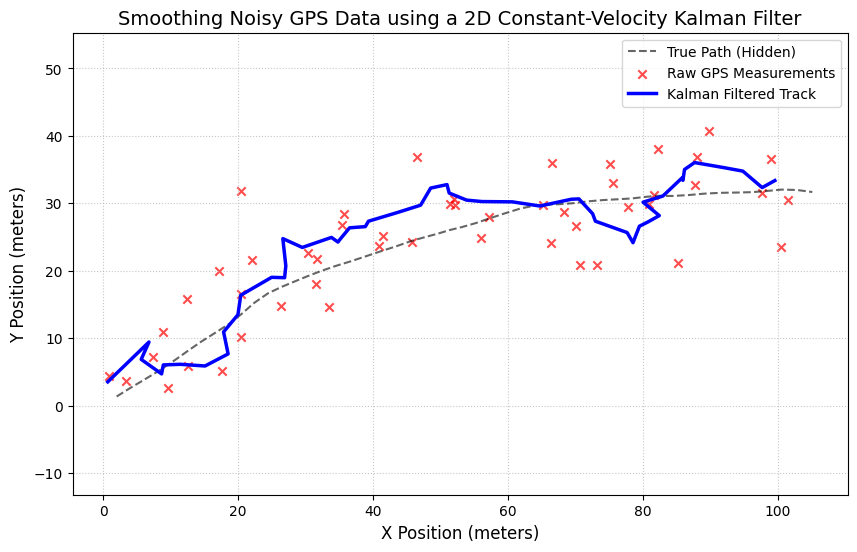

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Parameters ---
dt = 1.0  # Time step (e.g., GPS sampled every 1 second)
num_steps = 50

# State transition matrix (A): [px, py, vx, vy]^T
A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

# Measurement matrix (H): We only measure positions (px, py)
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# Process noise mapping matrix (G) and Covariance (Q)
# Simulates unknown random accelerations (e.g., wind, steering changes)
sigma_a = 0.2  # Process noise variance
G = np.array([
    [0.5 * dt**2, 0],
    [0, 0.5 * dt**2],
    [dt, 0],
    [0, dt]
])
# Q = G * Sigma_p * G^T
Q = G @ np.array([[sigma_a**2, 0], [0, sigma_a**2]]) @ G.T

# Measurement noise covariance (R): The inaccuracy of our GPS sensor
sigma_gps = 5.0  # Assumed 5 meters of GPS error variance
R = np.array([
    [sigma_gps**2, 0],
    [0, sigma_gps**2]
])

# --- 2. Generate Simulated GPS Data ---
# True initial state: start at (0,0) moving with vx=2.0, vy=1.5
true_x = np.array([0.0, 0.0, 2.0, 1.5])
true_positions = []
measurements = []

for _ in range(num_steps):
    # Update true state with some random process noise
    process_noise = G @ np.random.normal(0, sigma_a, 2)
    true_x = A @ true_x + process_noise
    true_positions.append((true_x[0], true_x[1]))

    # Generate a noisy GPS measurement (add observation noise)
    meas_noise = np.random.normal(0, sigma_gps, 2)
    y = H @ true_x + meas_noise
    measurements.append(y)

# --- 3. Kalman Filter Implementation ---
# Initial prior guesses
x_est = np.array([0.0, 0.0, 0.0, 0.0]) # Assume we start at origin, zero velocity
P_est = np.eye(4) * 50.0               # High initial uncertainty matrix (P_0)

filtered_positions = []

for y in measurements:
    # ---------------------------
    # Predict Step (Prior)
    # ---------------------------
    x_pred = A @ x_est
    P_pred = A @ P_est @ A.T + Q

    # ---------------------------
    # Update Step (Posterior)
    # ---------------------------
    # Innovation covariance S = H*P*H^T + R
    S = H @ P_pred @ H.T + R

    # Kalman Gain K = P*H^T*S^-1
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Update state estimate with measurement y
    x_est = x_pred + K @ (y - H @ x_pred)

    # Update covariance P = (I - K*H)*P
    I = np.eye(4)
    P_est = (I - K @ H) @ P_pred

    # Store the filtered coordinate
    filtered_positions.append((x_est[0], x_est[1]))

# --- 4. Plotting the Results ---
true_positions = np.array(true_positions)
measurements = np.array(measurements)
filtered_positions = np.array(filtered_positions)

plt.figure(figsize=(10, 6))
plt.plot(true_positions[:, 0], true_positions[:, 1], 'k--', alpha=0.6, label='True Path (Hidden)')
plt.scatter(measurements[:, 0], measurements[:, 1], c='red', marker='x', alpha=0.7, label='Raw GPS Measurements')
plt.plot(filtered_positions[:, 0], filtered_positions[:, 1], 'b-', linewidth=2.5, label='Kalman Filtered Track')

plt.title('Smoothing Noisy GPS Data using a 2D Constant-Velocity Kalman Filter', fontsize=14)
plt.xlabel('X Position (meters)', fontsize=12)
plt.ylabel('Y Position (meters)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.axis('equal')
plt.show()